In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch.nn as nn
import torch.nn.functional as F
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import random
import cv2
import sys

In [3]:
class MRI(Dataset):
    def __init__(self):
        
        tumor = []
        healthy = []
        
        for f in glob.iglob("./data/brain_tumor_dataset/yes/*.jpg"):
            img = cv2.imread(f)
            img = cv2.resize(img,(128,128)) 
            b, g, r = cv2.split(img)
            img = cv2.merge([r,g,b])
            img = img.reshape((img.shape[2],img.shape[0],img.shape[1])) 
            tumor.append(img)

        for f in glob.iglob("./data/brain_tumor_dataset/no/*.jpg"):
            img = cv2.imread(f)
            img = cv2.resize(img,(128,128)) 
            b, g, r = cv2.split(img)
            img = cv2.merge([r,g,b])
            img = img.reshape((img.shape[2],img.shape[0],img.shape[1]))
            healthy.append(img)

        # our images
        tumor = np.array(tumor,dtype=np.float32)
        healthy = np.array(healthy,dtype=np.float32)
        
        # our labels
        tumor_label = np.ones(tumor.shape[0], dtype=np.float32)
        healthy_label = np.zeros(healthy.shape[0], dtype=np.float32)
        
        # Concatenates
        self.images = np.concatenate((tumor, healthy), axis=0)
        self.labels = np.concatenate((tumor_label, healthy_label))
        
    def __len__(self):
        return self.images.shape[0]
    
    def __getitem__(self, index):
        
        sample = {'image': self.images[index], 'label':self.labels[index]}
        
        return sample
    
    def normalize(self):
        self.images = self.images/255.0

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.cnn_model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2, stride=5),
        nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
        nn.Tanh(),
        nn.AvgPool2d(kernel_size=2, stride=5))
        
        self.fc_model = nn.Sequential(
        nn.Linear(in_features=256, out_features=120),
        nn.Tanh(),
        nn.Linear(in_features=120, out_features=84),
        nn.Tanh(),
        nn.Linear(in_features=84, out_features=1))
        
    def forward(self, x):
        x = self.cnn_model(x)
        x = x.view(x.size(0), -1)
        x = self.fc_model(x)
        x = F.sigmoid(x)
        
        return x
            

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# Load data
mri_dataset = MRI()
mri_dataset.normalize()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

# Model, optimizer, loss
eta = 0.0001
EPOCH = 400
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=eta)
dataloader = DataLoader(mri_dataset, batch_size=32, shuffle=True)
model.train()

CNN(
  (cnn_model): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=5, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=5, padding=0)
  )
  (fc_model): Sequential(
    (0): Linear(in_features=256, out_features=120, bias=True)
    (1): Tanh()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): Tanh()
    (4): Linear(in_features=84, out_features=1, bias=True)
  )
)

In [9]:
for epoch in range(1, EPOCH):
    losses = []
    for D in dataloader:
        optimizer.zero_grad()
        data = D['image'].to(device)
        label = D['label'].to(device)
        y_hat = model(data)
        # define loss function
        error = nn.BCELoss() 
        loss = torch.sum(error(y_hat.squeeze(), label))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print('Train Epoch: {}\tLoss: {:.6f}'.format(epoch+1, np.mean(losses)))

Train Epoch: 10	Loss: 0.620374
Train Epoch: 20	Loss: 0.604655
Train Epoch: 30	Loss: 0.569115
Train Epoch: 40	Loss: 0.529210
Train Epoch: 50	Loss: 0.500999
Train Epoch: 60	Loss: 0.482602
Train Epoch: 70	Loss: 0.476465
Train Epoch: 80	Loss: 0.452853
Train Epoch: 90	Loss: 0.437054
Train Epoch: 100	Loss: 0.410931
Train Epoch: 110	Loss: 0.400458
Train Epoch: 120	Loss: 0.379112
Train Epoch: 130	Loss: 0.356173
Train Epoch: 140	Loss: 0.345013
Train Epoch: 150	Loss: 0.334766
Train Epoch: 160	Loss: 0.313864
Train Epoch: 170	Loss: 0.292380
Train Epoch: 180	Loss: 0.281939
Train Epoch: 190	Loss: 0.265622
Train Epoch: 200	Loss: 0.261675
Train Epoch: 210	Loss: 0.249324
Train Epoch: 220	Loss: 0.240190
Train Epoch: 230	Loss: 0.217387
Train Epoch: 240	Loss: 0.198378
Train Epoch: 250	Loss: 0.173596
Train Epoch: 260	Loss: 0.163756
Train Epoch: 270	Loss: 0.141998
Train Epoch: 280	Loss: 0.137122
Train Epoch: 290	Loss: 0.119037
Train Epoch: 300	Loss: 0.108356
Train Epoch: 310	Loss: 0.118596
Train Epoch: 320	

In [10]:
model.eval()
dataloader = DataLoader(mri_dataset, batch_size=32, shuffle=False)
outputs=[]
y_true = []
with torch.no_grad():
    for D in dataloader:
        image =  D['image'].to(device)
        label = D['label'].to(device)
        
        y_hat = model(image)
        
        outputs.append(y_hat.cpu().detach().numpy())
        y_true.append(label.cpu().detach().numpy())
        
outputs = np.concatenate( outputs, axis=0 )
y_true = np.concatenate( y_true, axis=0 )


In [12]:
def threshold(scores, threshold=0.5, minimum=0, maximum=1.0):
    x = np.array(list(scores))
    x[x >= threshold] = maximum
    x[x < threshold] = minimum
    return x
accuracy_score(y_true, threshold(outputs))

0.9959183673469387

[Text(0, 0.5, 'Tumor'), Text(0, 1.5, 'Healthy')]

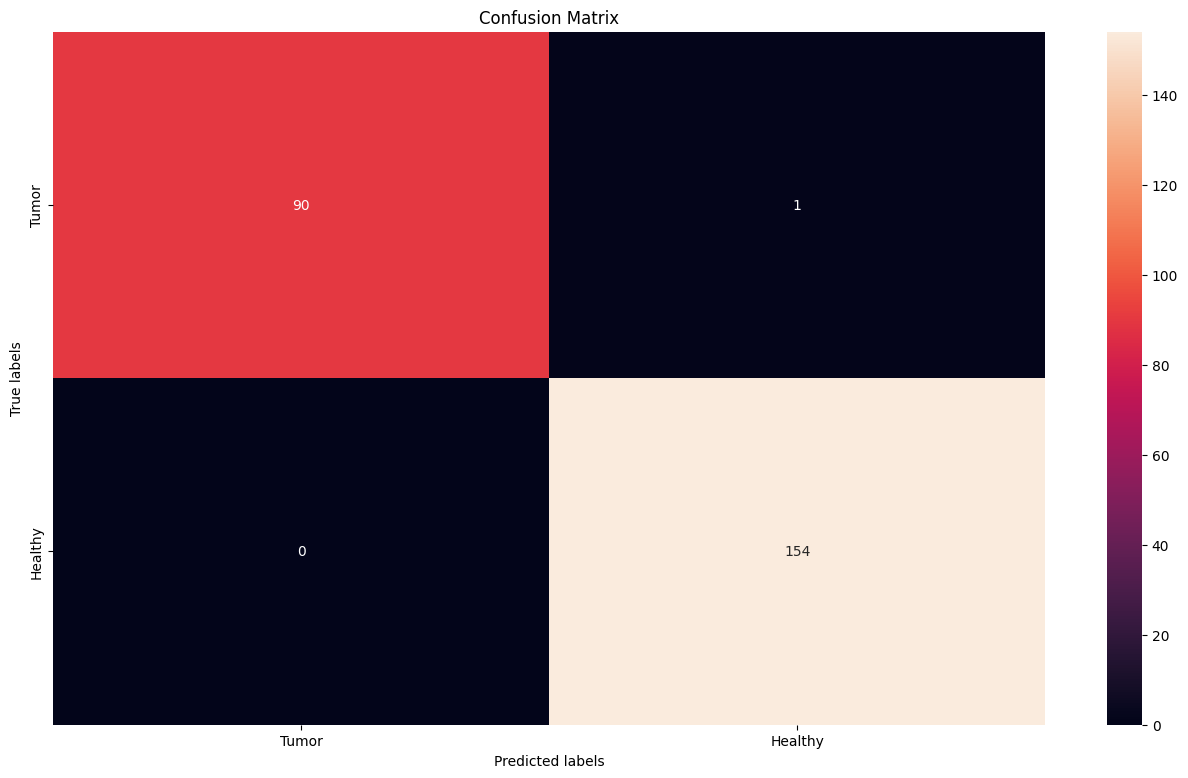

In [14]:
import seaborn as sns
cm = confusion_matrix(y_true, threshold(outputs))
plt.figure(figsize=(16,9))

ax= plt.subplot()
sns.heatmap(cm, annot=True, fmt='g', ax=ax);  

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['Tumor','Healthy'])
ax.yaxis.set_ticklabels(['Tumor','Healthy'])

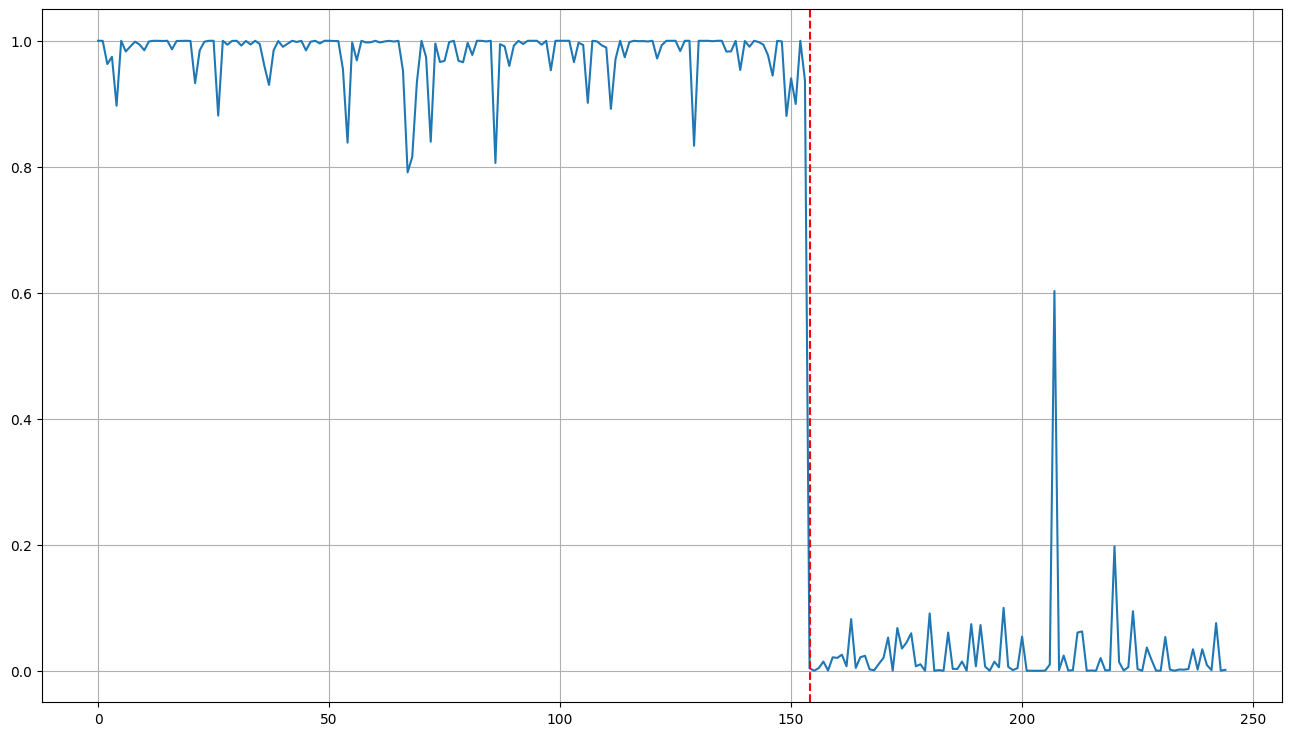

In [17]:
tumor_images = mri_dataset.images[mri_dataset.labels == 1]
num_tumor = len(tumor_images)
plt.figure(figsize=(16,9))
plt.plot(outputs)
plt.axvline(x=num_tumor, color='r', linestyle='--')
plt.grid()